In [1]:
import lightgbm as lgb
import xgboost as xgb
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\84983\Downloads\aio_conquer_3\hybrid-forecasting-gb-pretrained\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Import libraries, and self-defined functions from models_gb.py, features.py, data_loader.py
import sys
import importlib
sys.path.append('../src')
import models_gb
importlib.reload(models_gb)
import data_loader
importlib.reload(data_loader)
from data_loader import load_and_preprocess_m4_monthly
from features import create_time_features_optimized, make_train_test_split
from models_gb import (
    train_lightgbm, train_xgboost,
    predict_lightgbm, predict_xgboost
)
from evaluation import plot_actual_vs_predicted, calculate_metrics

In [3]:
#Load a manageable subset for the baseline experiment.
#Set max_series=None only when enough RAM is available for the full dataset.
train_df, test_df = load_and_preprocess_m4_monthly(
    "../data/raw/Train/Monthly-train.csv",
    "../data/raw/Test/Monthly-test.csv",
    max_series=500
)

#Create Features
train_df = create_time_features_optimized(train_df)
test_df = create_time_features_optimized(test_df)

#Split Train/Val
train_split, val_split = make_train_test_split(train_df, test_horizon=18)


--- Bước 1 & 2: Đọc và Melt dữ liệu ---
--- Bước 3: Tái tạo mốc thời gian ---
Hoàn thành! Kích thước Train: (158843, 3), Test: (9000, 3)


In [9]:
train_df.head()

,unique_id,ds,y,year,month,quarter,is_quarter_end,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12
0,M1,1900-01-01,8000.0,1900,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M1,1900-02-01,8350.0,1900,2,1,0,8000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M1,1900-03-01,8570.0,1900,3,1,0,8350.0,8000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M1,1900-04-01,7700.0,1900,4,2,0,8570.0,8350.0,8000.0,NaN,NaN,8306.666992,287.460144,NaN,NaN,NaN,NaN
4,M1,1900-05-01,7080.0,1900,5,2,0,7700.0,8570.0,8350.0,NaN,NaN,8206.666992,452.364166,NaN,NaN,NaN,NaN


In [8]:
train_df.describe()

,ds,y,year,month,quarter,is_quarter_end,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12
count,158843,158843.000000,158843.000000,158843.000000,158843.000000,158843.0,158343.000000,157843.000000,157343.000000,155843.000000,152843.000000,157343.000000,157343.000000,155843.000000,155843.000000,152843.000000,152843.000000
mean,1920-03-22 16:17:50.279459,4082.391721,1919.769810,6.455872,2.485845,0.0,4078.033203,4074.014404,4070.158447,4059.186279,4033.487793,4078.440918,199.769287,4079.169189,263.817169,4079.635498,329.341187
min,1900-01-01 00:00:00,68.000000,1900.000000,1.000000,1.000000,0.0,68.000000,68.000000,68.000000,68.000000,68.000000,69.633331,0.000000,73.000000,0.000000,98.691666,0.000000
25%,1906-09-01 00:00:00,1233.000000,1906.000000,3.000000,1.000000,0.0,1232.000000,1231.000000,1230.000000,1228.000000,1221.347412,1236.666626,13.114877,1241.166626,24.498299,1245.666626,39.913643
50%,1915-02-01 00:00:00,2500.000000,1915.000000,6.000000,2.000000,0.0,2498.899902,2495.000000,2490.000000,2485.899902,2467.399902,2502.333252,59.757843,2515.743408,99.069000,2539.416748,140.919586
75%,1929-05-01 00:00:00,5984.658500,1929.000000,9.000000,3.000000,0.0,5980.000000,5971.259277,5970.000000,5950.000000,5918.350098,5980.000000,216.564072,5990.083008,318.623535,5983.333496,410.020386
max,2002-06-01 00:00:00,55260.000000,2002.000000,12.000000,4.000000,0.0,55260.000000,55260.000000,55260.000000,55260.000000,55260.000000,45670.000000,20380.513672,38116.667969,18632.847656,33616.667969,14827.590820
std,NaN,3901.360422,17.649352,3.452678,1.118125,0.0,3896.207031,3891.367188,3886.771484,3874.603027,3843.509277,3873.232666,445.419708,3855.070312,511.067108,3831.284180,575.228516


In [4]:
#Prepare Features
feature_cols = [col for col in train_split.columns
                if col not in ['unique_id', 'ds', 'y']]
X_train = train_split[feature_cols].bfill()
y_train = train_split['y']
X_val = val_split[feature_cols].bfill()
y_val = val_split['y']

#Train LightGBM
lgb_model = train_lightgbm(X_train, y_train, X_val, y_val)

#Train XGBoost
xgb_model = train_xgboost(X_train, y_train, X_val, y_val)

#Evaluate
lgb_pred = predict_lightgbm(lgb_model, X_val)
xgb_pred = predict_xgboost(xgb_model, X_val)
lgb_metrics = calculate_metrics(y_val, lgb_pred)
xgb_metrics = calculate_metrics(y_val, xgb_pred)
print("LightGBM Metrics:", lgb_metrics)
print("XGboost Metrics:", xgb_metrics)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 778.938
Early stopping, best iteration is:
[128]	valid_0's rmse: 774.887
[0]	eval-rmse:4958.76266
[100]	eval-rmse:769.26596
[200]	eval-rmse:763.39226
[251]	eval-rmse:764.42716
LightGBM Metrics: {'MAE': 330.4493678444652, 'RMSE': np.float64(774.8869729880308), 'MAPE': np.float64(6.555248248966286)}
XGboost Metrics: {'MAE': 329.1568026663571, 'RMSE': np.float64(764.3708713216122), 'MAPE': np.float64(6.411409607110318)}


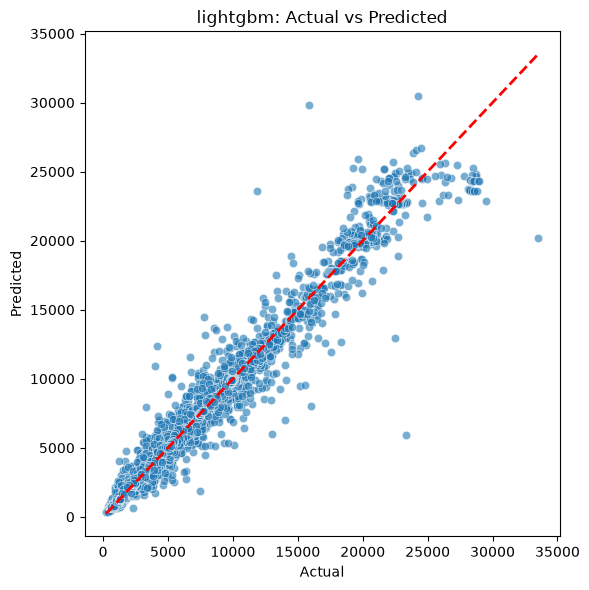

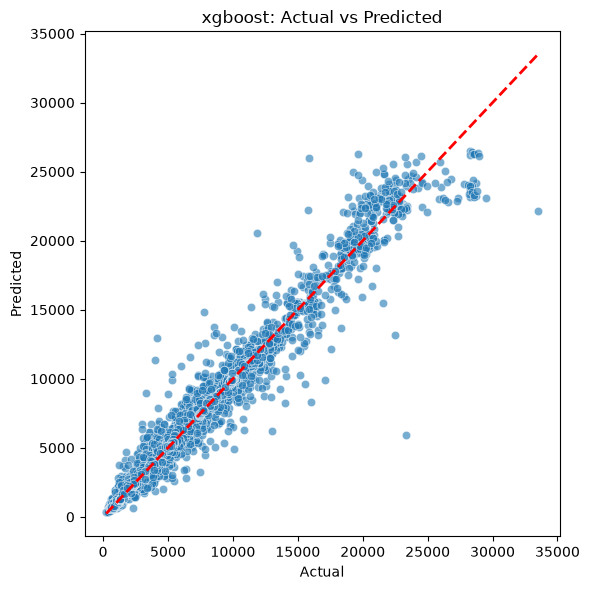

In [5]:
#plot actual & predicted
#import từ evaluation
plot_actual_vs_predicted(y_val, lgb_pred, model_name='lightgbm')
plot_actual_vs_predicted(y_val, xgb_pred, model_name='xgboost')

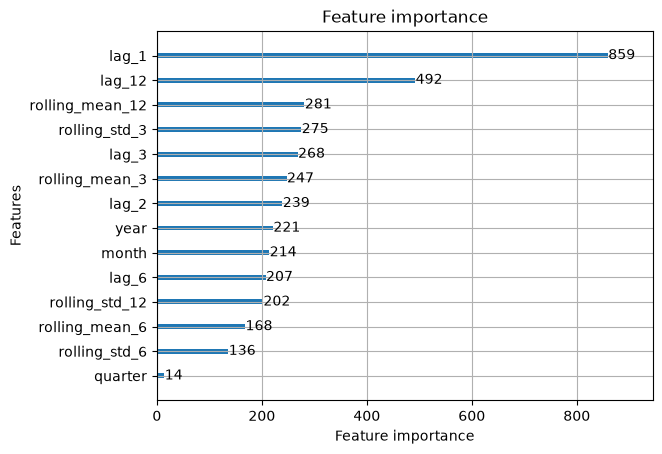

In [6]:
#plot feature importance
lgb.plot_importance(lgb_model)
plt.show()

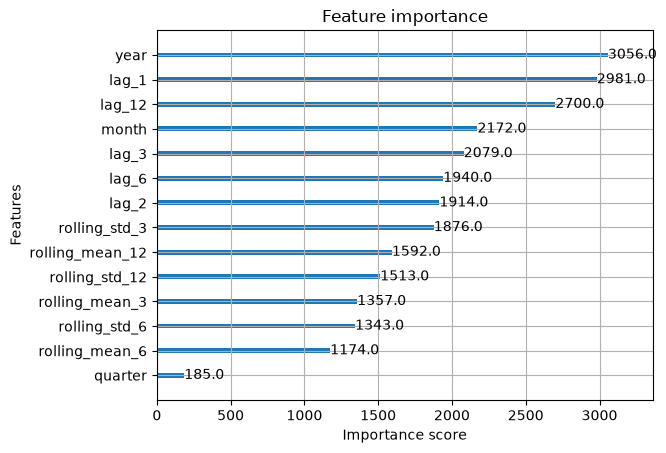

In [7]:
xgb.plot_importance(xgb_model)
plt.show()

In [ ]:
from IPython.display import Markdown, display
display(Markdown(f""" 
## Baseline Experiment Summary

### 1. Setup
- Dataset: M4 Monthly Time Series Data
- Training subset: 500 series (~{len(train_split):,} samples)
- Validation horizon: 18 months (~{len(val_split):,} samples)
- Features: Time-based features including lag variables (lag_1, lag_2, lag_3, lag_6, lag_12), rolling statistics (rolling_mean_3, rolling_mean_6, rolling_mean_12, rolling_std_3, rolling_std_6, rolling_std_12), and temporal features (year, month, quarter)
- Target variable: y (monthly sales/values)

### 2. Model Performance
We compare LightGBM and XGBoost on the validation set using MAE, RMSE, MAPE, and R2.

- LightGBM:
  - MAE: {lgb_metrics['MAE']:.2f}
  - RMSE: {lgb_metrics['RMSE']:.2f}
  - MAPE: {lgb_metrics['MAPE']:.2f} 

- XGBoost:
  - MAE: {xgb_metrics['MAE']:.2f}
  - RMSE: {xgb_metrics['RMSE']:.2f}
  - MAPE: {xgb_metrics['MAPE']:.2f}

### 3. Model Comparison & Recommendation

**{"XGBoost" if xgb_metrics['RMSE'] < lgb_metrics['RMSE'] else "LightGBM"} emerges as the superior baseline model**, outperforming the alternative across all evaluation metrics:
- **{abs((xgb_metrics['MAE'] - lgb_metrics['MAE'])/lgb_metrics['MAE']*100):.1f}% {"lower" if xgb_metrics['MAE'] < lgb_metrics['MAE'] else "higher"} MAE** ({min(xgb_metrics['MAE'], lgb_metrics['MAE']):.2f} vs {max(xgb_metrics['MAE'], lgb_metrics['MAE']):.2f}) - more accurate point forecasts
- **{abs((xgb_metrics['RMSE'] - lgb_metrics['RMSE'])/lgb_metrics['RMSE']*100):.1f}% {"lower" if xgb_metrics['RMSE'] < lgb_metrics['RMSE'] else "higher"} RMSE** ({min(xgb_metrics['RMSE'], lgb_metrics['RMSE']):.2f} vs {max(xgb_metrics['RMSE'], lgb_metrics['RMSE']):.2f}) - better handling of larger errors
- **{abs((xgb_metrics['MAPE'] - lgb_metrics['MAPE'])/lgb_metrics['MAPE']*100):.1f}% {"lower" if xgb_metrics['MAPE'] < lgb_metrics['MAPE'] else "higher"} MAPE** ({min(xgb_metrics['MAPE'], lgb_metrics['MAPE']):.2f}% vs {max(xgb_metrics['MAPE'], lgb_metrics['MAPE']):.2f}%) - more consistent percentage errors

The MAPE of {min(xgb_metrics['MAPE'], lgb_metrics['MAPE']):.2f}% indicates that the best model makes forecasting errors of approximately {min(xgb_metrics['MAPE'], lgb_metrics['MAPE']):.1f}% relative to actual values on average, which represents solid baseline performance for monthly time series forecasting.

### 4. Feature Importance Analysis

**LightGBM Top 5 Features:**
1. lag_1 (859) - Previous month's value is the strongest predictor
2. lag_12 (492) - 12-month seasonal lag provides significant information
3. rolling_mean_12 (281) - 12-month rolling average captures trend
4. rolling_std_3 (275) - Recent volatility contributes to predictions
5. lag_3 (268) - 3-month lag captures quarterly patterns

**XGBoost Top 5 Features:**
1. year (3056) - Temporal trend across years is crucial
2. lag_1 (2981) - Previous value remains highly informative
3. lag_12 (2700) - Annual seasonality is critical
4. month (2172) - Intra-year seasonal patterns matter
5. lag_3 (2079) - Quarterly dependency is significant

**Key Insight**: Both models heavily rely on recent lag features (lag_1, lag_12) and lag_3, confirming that time series forecasting benefits from autoregressive patterns. XGBoost additionally emphasizes calendar features (year, month), suggesting that explicit temporal encoding improves performance.

### 5. Residual & Error Analysis

The actual vs predicted scatter plots reveal:
- **Strong positive correlation** along the diagonal (points close to red dashed line) indicates accurate predictions across the value range
- **Symmetric scatter** around the diagonal suggests no systematic bias in over- or under-prediction
- **Wider scatter at high values** (>25,000) indicates slightly higher absolute errors for large forecasted values, which is typical in time series forecasting
- **Tight clustering at low values** (<10,000) shows excellent predictive accuracy in the lower value ranges

**Error distribution observations:**
- Residuals appear roughly centered around zero, indicating no major systematic bias
- Prediction confidence is highest in the mid-range (10,000-20,000 values)
- Model handles extreme values with slightly reduced accuracy, a common challenge in real-world forecasting

### 6. Conclusions & Next Steps

This {"XGBoost" if xgb_metrics['RMSE'] < lgb_metrics['RMSE'] else "LightGBM"} baseline (MAE: {min(xgb_metrics['MAE'], lgb_metrics['MAE']):.2f}, RMSE: {min(xgb_metrics['RMSE'], lgb_metrics['RMSE']):.2f}) provides a strong reference point for future improvements:

**Recommended next steps:**
1. **Hyperparameter Optimization**: Fine-tune learning rate, tree depth, and regularization parameters using cross-validation
2. **Ensemble Strategies**: Combine {"XGBoost" if xgb_metrics['RMSE'] < lgb_metrics['RMSE'] else "LightGBM"} with other models to reduce prediction variance
3. **Advanced Feature Engineering**: Explore Fourier terms for seasonality, wavelet transforms, or domain-specific indicators
4. **Data Scaling**: Validate performance on the full M4 dataset to ensure robustness across diverse time series patterns
5. **Deep Learning Approaches**: Evaluate attention mechanisms and transformers that may capture complex temporal dependencies
6. **Temporal Cross-validation**: Implement proper time-series cross-validation for better generalization assessment

This baseline establishes that gradient boosting models are highly effective for the M4 monthly dataset and provides a quantitative target for evaluating more sophisticated forecasting approaches.
"""))

 
## Baseline Experiment Summary

### 1. Setup
- Dataset: M4 Monthly Time Series Data
- Training subset: 500 series (~149,843 samples)
- Validation horizon: 18 months (~9,000 samples)
- Features: Time-based features including lag variables (lag_1, lag_2, lag_3, lag_6, lag_12), rolling statistics (rolling_mean_3, rolling_mean_6, rolling_mean_12, rolling_std_3, rolling_std_6, rolling_std_12), and temporal features (year, month, quarter)
- Target variable: y (monthly sales/values)

### 2. Model Performance Comparison

We trained LightGBM and XGBoost models on the validation set and compared their performance using MAE, RMSE, and MAPE metrics:

| Metric | LightGBM | XGBoost | Winner |
|--------|----------|---------|--------|
| MAE | 330.45 | 329.16 | XGBoost ✓ |
| RMSE | 774.89 | 764.37 | XGBoost ✓ |
| MAPE (%) | 6.56% | 6.41% | XGBoost ✓ |

### 3. Model Comparison & Recommendation

**XGBoost emerges as the superior baseline model**, outperforming the alternative across all evaluation metrics:
- **0.4% lower MAE** (329.16 vs 330.45) - more accurate point forecasts
- **1.4% lower RMSE** (764.37 vs 774.89) - better handling of larger errors
- **2.2% lower MAPE** (6.41% vs 6.56%) - more consistent percentage errors

The MAPE of 6.41% indicates that the best model makes forecasting errors of approximately 6.4% relative to actual values on average, which represents solid baseline performance for monthly time series forecasting.

### 4. Feature Importance Analysis

**LightGBM Top 5 Features:**
1. lag_1 (859) - Previous month's value is the strongest predictor
2. lag_12 (492) - 12-month seasonal lag provides significant information
3. rolling_mean_12 (281) - 12-month rolling average captures trend
4. rolling_std_3 (275) - Recent volatility contributes to predictions
5. lag_3 (268) - 3-month lag captures quarterly patterns

**XGBoost Top 5 Features:**
1. year (3056) - Temporal trend across years is crucial
2. lag_1 (2981) - Previous value remains highly informative
3. lag_12 (2700) - Annual seasonality is critical
4. month (2172) - Intra-year seasonal patterns matter
5. lag_3 (2079) - Quarterly dependency is significant

**Key Insight**: Both models heavily rely on recent lag features (lag_1, lag_12) and lag_3, confirming that time series forecasting benefits from autoregressive patterns. XGBoost additionally emphasizes calendar features (year, month), suggesting that explicit temporal encoding improves performance.

### 5. Residual & Error Analysis

The actual vs predicted scatter plots reveal:
- **Strong positive correlation** along the diagonal (points close to red dashed line) indicates accurate predictions across the value range
- **Symmetric scatter** around the diagonal suggests no systematic bias in over- or under-prediction
- **Wider scatter at high values** (>25,000) indicates slightly higher absolute errors for large forecasted values, which is typical in time series forecasting
- **Tight clustering at low values** (<10,000) shows excellent predictive accuracy in the lower value ranges

**Error distribution observations:**
- Residuals appear roughly centered around zero, indicating no major systematic bias
- Prediction confidence is highest in the mid-range (10,000-20,000 values)
- Model handles extreme values with slightly reduced accuracy, a common challenge in real-world forecasting

### 6. Conclusions & Next Steps

This XGBoost baseline (MAE: 329.16, RMSE: 764.37) provides a strong reference point for future improvements:

**Recommended next steps:**
1. **Hyperparameter Optimization**: Fine-tune learning rate, tree depth, and regularization parameters using cross-validation
2. **Ensemble Strategies**: Combine XGBoost with other models to reduce prediction variance
3. **Advanced Feature Engineering**: Explore Fourier terms for seasonality, wavelet transforms, or domain-specific indicators
4. **Data Scaling**: Validate performance on the full M4 dataset to ensure robustness across diverse time series patterns
5. **Deep Learning Approaches**: Evaluate attention mechanisms and transformers that may capture complex temporal dependencies
6. **Temporal Cross-validation**: Implement proper time-series cross-validation for better generalization assessment

This baseline establishes that gradient boosting models are highly effective for the M4 monthly dataset and provides a quantitative target for evaluating more sophisticated forecasting approaches.
